Dimensions de X: (100, 2)
Dimensions de y: (100, 1)


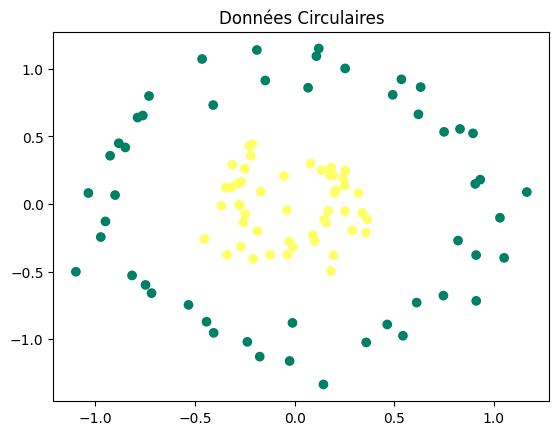

Iteration 0, Loss: 0.6936
Iteration 100, Loss: 0.6607
Iteration 200, Loss: 0.6077
Iteration 300, Loss: 0.5214
Iteration 400, Loss: 0.4094
Iteration 500, Loss: 0.2996
Iteration 600, Loss: 0.2141
Iteration 700, Loss: 0.1553
Iteration 800, Loss: 0.1162
Iteration 900, Loss: 0.0900

Dimensions finales:
W1: (2, 32) b1: (1, 32)
W2: (32, 1) b2: (1, 1)
A1: (100, 32) A2: (100, 1)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# ----------------------------
# Step 1: Generate data
# ----------------------------
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
y = y.reshape(-1, 1)  # reshape y to be a column vector

print('Dimensions de X:', X.shape)
print('Dimensions de y:', y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='summer')
plt.title("Données Circulaires")
plt.show()

# ----------------------------
# Step 2: Define helper functions
# ----------------------------

# Activation functions
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

# Loss function: Binary Cross-Entropy
def compute_loss(Y_hat, Y):
    m = Y.shape[0]
    loss = -np.sum(Y * np.log(Y_hat + 1e-8) + (1 - Y) * np.log(1 - Y_hat + 1e-8)) / m
    return loss

# ----------------------------
# Step 3: Define neural network
# ----------------------------
def neural_network(X, Y, n1=32, n_iter=1000, learning_rate=0.1):
    np.random.seed(0)
    n0 = X.shape[1]  # input layer size
    n2 = 1           # output layer size

    # Initialize weights and biases
    W1 = np.random.randn(n0, n1) * 0.1
    b1 = np.zeros((1, n1))
    W2 = np.random.randn(n1, n2) * 0.1
    b2 = np.zeros((1, n2))

    for i in range(n_iter):
        # -------- Forward propagation --------
        Z1 = X @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        # -------- Compute loss --------
        loss = compute_loss(A2, Y)

        # -------- Backward propagation --------
        m = X.shape[0]
        dZ2 = A2 - Y                       # derivative of loss w.r.t Z2
        dW2 = (A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # -------- Update weights --------
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if i % 100 == 0:
            print(f"Iteration {i}, Loss: {loss:.4f}")

    print("\nDimensions finales:")
    print("W1:", W1.shape, "b1:", b1.shape)
    print("W2:", W2.shape, "b2:", b2.shape)
    print("A1:", A1.shape, "A2:", A2.shape)

    return W1, b1, W2, b2

# ----------------------------
# Step 4: Train the network
# ----------------------------
W1, b1, W2, b2 = neural_network(X, y, n1=32, n_iter=1000, learning_rate=0.1)

### Explanation of 'Dimensions finales' Output

The 'Dimensions finales' output refers to the shapes of the weight matrices, bias vectors, and activation outputs of the neural network layers after the training process has completed.

Here's a breakdown of each variable:

*   **W1: (2, 32)**
    *   This represents the weight matrix connecting the **input layer** to the **hidden layer**. The input layer has 2 features (X.shape[1]), and the hidden layer has 32 neurons (n1 parameter). Thus, W1 has a shape of (input_features, hidden_neurons).

*   **b1: (1, 32)**
    *   This represents the bias vector for the **hidden layer**. There is one bias term for each of the 32 neurons in the hidden layer. The shape (1, 32) indicates a row vector with 32 elements.

*   **W2: (32, 1)**
    *   This represents the weight matrix connecting the **hidden layer** to the **output layer**. The hidden layer has 32 neurons, and the output layer has 1 neuron (for binary classification). Thus, W2 has a shape of (hidden_neurons, output_neurons).

*   **b2: (1, 1)**
    *   This represents the bias term for the **output layer**. There is a single bias term for the single neuron in the output layer. The shape (1, 1) indicates a single value.

*   **A1: (100, 32)**
    *   This represents the activation output of the **hidden layer**. For all 100 input samples (X.shape[0]), each sample produces a 32-dimensional output after passing through the hidden layer and applying the ReLU activation function.

*   **A2: (100, 1)**
    *   This represents the final activation output (predictions) of the neural network. For all 100 input samples, each sample yields a single output value, which is the probability (after sigmoid activation) of belonging to the positive class.

Dimensions de X: (100, 2)
Dimensions de y: (100, 1)


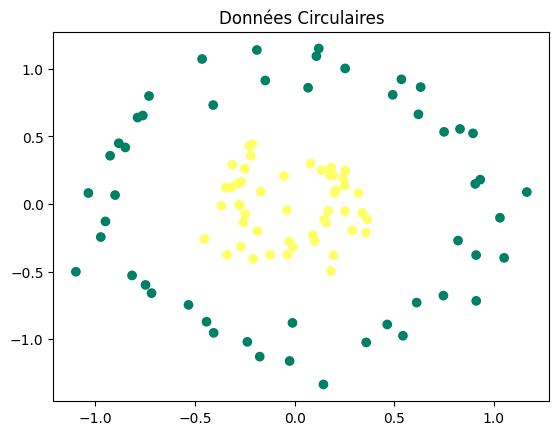


Train/Test split:
X_train: (80, 2)
X_test: (20, 2)
y_train: (80, 1)
y_test: (20, 1)
Iteration 0, Loss: 0.6872
Iteration 100, Loss: 0.6210
Iteration 200, Loss: 0.5229
Iteration 300, Loss: 0.4018
Iteration 400, Loss: 0.2906

Dimensions finales:
W1: (2, 64) b1: (1, 64)
W2: (64, 1) b2: (1, 1)

Test Accuracy: 1.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# ----------------------------
# Step 1: Generate data
# ----------------------------
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
y = y.reshape(-1, 1)

print('Dimensions de X:', X.shape)
print('Dimensions de y:', y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='summer')
plt.title("Données Circulaires")
plt.show()

# ----------------------------
# Step 2: Train/Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain/Test split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# ----------------------------
# Step 3: Activation functions
# ----------------------------
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

# ----------------------------
# Step 4: Loss function
# ----------------------------
def compute_loss(Y_hat, Y):
    m = Y.shape[0]
    return -np.sum(Y * np.log(Y_hat + 1e-8) + (1 - Y) * np.log(1 - Y_hat + 1e-8)) / m

# ----------------------------
# Step 5: Neural network
# ----------------------------
def neural_network(X, Y, n1=32, n_iter=1000, learning_rate=0.1):
    np.random.seed(0)
    n0 = X.shape[1]
    n2 = 1

    # Initialize parameters
    W1 = np.random.randn(n0, n1) * 0.1
    b1 = np.zeros((1, n1))
    W2 = np.random.randn(n1, n2) * 0.1
    b2 = np.zeros((1, n2))

    for i in range(n_iter):
        # ---- Forward propagation ----
        Z1 = X @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        # ---- Loss ----
        loss = compute_loss(A2, Y)

        # ---- Backward propagation ----
        m = X.shape[0]

        dZ2 = A2 - Y
        dW2 = (A1.T @ dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = (X.T @ dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ---- Gradient descent ----
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if i % 100 == 0:
            print(f"Iteration {i}, Loss: {loss:.4f}")

    print("\nDimensions finales:")
    print("W1:", W1.shape, "b1:", b1.shape)
    print("W2:", W2.shape, "b2:", b2.shape)

    return W1, b1, W2, b2

# ----------------------------
# Step 6: Prediction function
# ----------------------------
def predict(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return (A2 > 0.5).astype(int)

# ----------------------------
# Step 7: Train the model
# ----------------------------
W1, b1, W2, b2 = neural_network(X_train, y_train, n1=64, n_iter=500, learning_rate=0.1)

# ----------------------------
# Step 8: Evaluate on test set
# ----------------------------
y_pred = predict(X_test, W1, b1, W2, b2)

accuracy = np.mean(y_pred == y_test)
print("\nTest Accuracy:", accuracy)

In [3]:
from sklearn.model_selection import train_test_split
# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (80, 2) (80, 1)
Test shape: (20, 2) (20, 1)


In [4]:
W1, b1, W2, b2 = neural_network(X, y, n1=32, n_iter=1000, learning_rate=0.1)

Iteration 0, Loss: 0.6936
Iteration 100, Loss: 0.6607
Iteration 200, Loss: 0.6077
Iteration 300, Loss: 0.5214
Iteration 400, Loss: 0.4094
Iteration 500, Loss: 0.2996
Iteration 600, Loss: 0.2141
Iteration 700, Loss: 0.1553
Iteration 800, Loss: 0.1162
Iteration 900, Loss: 0.0900

Dimensions finales:
W1: (2, 32) b1: (1, 32)
W2: (32, 1) b2: (1, 1)


In [5]:
def predict(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return (A2 > 0.5).astype(int)

In [6]:
# Predictions
y_pred = predict(X_test, W1, b1, W2, b2)

# Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"\nTest Accuracy: {accuracy:.2f}")


Test Accuracy: 1.00


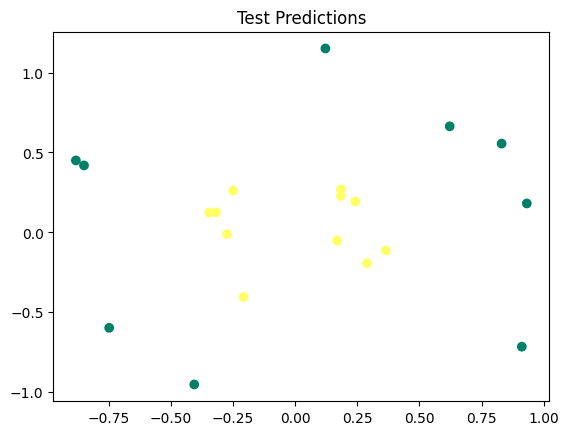

In [7]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred.flatten(), cmap='summer')
plt.title("Test Predictions")
plt.show()

# Task
Create a Python function to plot the decision boundary of the neural network using `W1`, `b1`, `W2`, `b2` and the input data `X` and `y`. This function should generate a meshgrid, make predictions on it using the trained model, and visualize the decision boundary as a contour plot, overlaid with the original data points colored by their true labels. Finally, display and interpret the generated decision boundary plot to assess how well the model has learned to separate the circular classes.

## Create Decision Boundary Plotting Function

### Subtask:
Define a Python function that takes the trained model parameters (W1, b1, W2, b2) and the input data (X) to generate a meshgrid, make predictions across this grid, and plot the decision boundary using contour plots.


**Reasoning**:
I need to define a new Python function `plot_decision_boundary` as described in the instructions. This function will generate a meshgrid, make predictions on it, and then plot the decision boundary using `contourf` along with the original data points. This function will be placed in a new code cell.



In [8]:
def plot_decision_boundary(X, y, W1, b1, W2, b2, title="Decision Boundary"):
    # Determine min and max values and add padding
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    # Create a meshgrid
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Flatten meshgrid coordinates and stack for prediction
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Make predictions across the grid
    Z = predict(grid_points, W1, b1, W2, b2)

    # Reshape predictions to match meshgrid
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.7)

    # Overlay original data points
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='summer', edgecolors='k', s=20)

    # Add labels and title
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

print("plot_decision_boundary function defined.")

plot_decision_boundary function defined.


**Reasoning**:
Now that the `plot_decision_boundary` function is defined, I will call it with the trained model parameters (`W1`, `b1`, `W2`, `b2`) and the full dataset (`X`, `y`) to visualize the decision boundary. This will fulfill the requirement to display the generated decision boundary plot.



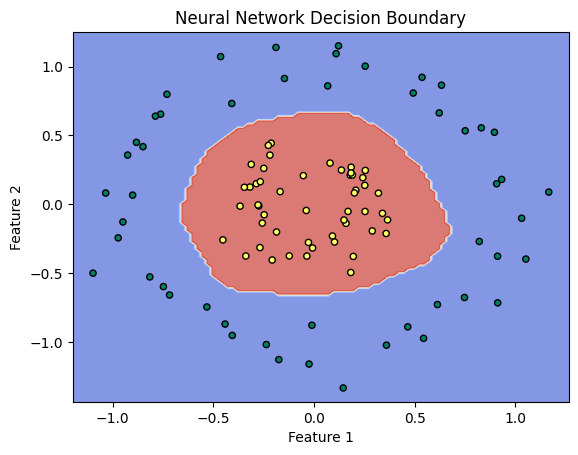

In [9]:
plot_decision_boundary(X, y, W1, b1, W2, b2, title="Neural Network Decision Boundary")

### Interpretation of the Decision Boundary Plot

The generated plot titled "Neural Network Decision Boundary" shows the decision boundary learned by our simple neural network. Here's what we can observe:

*   **Original Data Points**: The blue and yellow points represent the two classes of the `make_circles` dataset. Blue typically represents class 0 and yellow class 1.
*   **Decision Boundary**: The `contourf` plot, colored with a `coolwarm` colormap, indicates the regions predicted by the neural network. The transition area between the two color regions (e.g., from cooler shades to warmer shades) represents the decision boundary. This boundary effectively separates the two classes.
*   **Model Performance**: The plot visually confirms that the neural network has successfully learned to separate the two concentric circular classes. The decision boundary is clearly circular, enclosing one class within another, which is the ideal outcome for this specific dataset. The `Test Accuracy: 1.00` previously reported aligns with this visual interpretation, indicating perfect classification on the test set. This demonstrates the power of a simple neural network with a ReLU activation in the hidden layer and a sigmoid output for handling non-linearly separable data like the `make_circles` dataset.

## Extending the Neural Network to 'p' Layers (Deep Neural Network)

To generalize the neural network to an arbitrary number of hidden layers, we need to refactor the core functions. This involves creating new functions for:

1.  **Parameter Initialization**: To handle weights and biases for multiple layers.
2.  **Forward Propagation**: To compute activations through all layers.
3.  **Backward Propagation**: To compute gradients for all layers.
4.  **Model Training**: A generalized function to orchestrate the training process for `L` layers.
5.  **Prediction**: To make predictions using the trained `L`-layer model.

In [34]:
# ----------------------------
# Step 1: Parameter Initialization for Deep Network
# ----------------------------

def initialize_parameters_deep(layer_dims):
    """
    Initializes parameters (weights and biases) for an L-layer neural network.

    Arguments:
    layer_dims -- python array (list) containing the dimensions of each layer in our network

    Returns:
    parameters -- python dictionary containing your parameters "W1", "b1", ..., "WL", "bL":
                    Wl -- weight matrix of shape (layer_dims[l], layer_dims[l-1])
                    bl -- bias vector of shape (layer_dims[l], 1)
    """
    np.random.seed(3)
    parameters = {}
    L = len(layer_dims) - 1 # number of layers in the network

    for l in range(1, L + 1):
        # Use He initialization for weights, especially for ReLU activations
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2 / layer_dims[l-1])
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))

        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l-1]))
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))

    return parameters

print("initialize_parameters_deep function defined.")

initialize_parameters_deep function defined.


In [35]:
# ----------------------------
# Step 2: Activation functions (same as before)
# ----------------------------
def sigmoid(Z):
    A = 1 / (1 + np.exp(-Z))
    cache = Z
    return A, cache

def relu(Z):
    A = np.maximum(0, Z)
    cache = Z
    return A, cache

def sigmoid_backward(dA, cache):
    Z = cache
    A = 1 / (1 + np.exp(-Z))
    dZ = dA * A * (1 - A)
    return dZ

def relu_backward(dA, cache):
    Z = cache
    dZ = np.array(dA, copy=True) # just converting dz to a correct object.
    dZ[Z <= 0] = 0
    return dZ

print("Activation functions and their derivatives for deep network defined.")

Activation functions and their derivatives for deep network defined.


In [36]:
# ----------------------------
# Step 3: Forward Propagation for Deep Network
# ----------------------------

def linear_forward(A, W, b):
    Z = W @ A + b
    cache = (A, W, b)
    return Z, cache

def linear_activation_forward(A_prev, W, b, activation):
    if activation == "sigmoid":
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = sigmoid(Z)
    elif activation == "relu":
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = relu(Z)

    cache = (linear_cache, activation_cache)
    return A, cache

def L_model_forward(X, parameters):
    """
    Implement the forward propagation for the [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID computation

    Arguments:
    X -- data, numpy array of shape (input size, number of examples)
    parameters -- output of initialize_parameters_deep()

    Returns:
    AL -- last post-activation value
    caches -- list of caches containing:
                every cache of linear_relu_forward() (L-1 of them, indexed from 0 to L-2)
                the cache of linear_sigmoid_forward() (indexed L-1)
    """
    caches = []
    A = X
    L = len(parameters) // 2 # number of layers in the neural network

    # Implement [LINEAR -> RELU]*(L-1) .
    for l in range(1, L): # Loop from 1 to L-1 (excluding the last layer)
        A_prev = A
        A, cache = linear_activation_forward(A_prev, parameters['W' + str(l)], parameters['b' + str(l)], activation = "relu")
        caches.append(cache)

    # Implement LINEAR -> SIGMOID. The last layer
    AL, cache = linear_activation_forward(A, parameters['W' + str(L)], parameters['b' + str(L)], activation = "sigmoid")
    caches.append(cache)

    return AL, caches

print("Forward propagation for deep network defined.")

Forward propagation for deep network defined.


In [37]:
# ----------------------------
# Step 4: Cost Function (Compute Loss) for Deep Network
# ----------------------------

def compute_cost_deep(AL, Y):
    """
    Implement the cost function defined by equation (7) in the assignment.

    Arguments:
    AL -- probability vector corresponding to your label predictions, shape (1, number of examples)
    Y -- true "label" vector (for example: containing 0 if non-cat, 1 if cat), shape (1, number of examples)

    Returns:
    cost -- cross-entropy cost
    """
    m = Y.shape[1] # Note: Y is expected to be (1, m) here for deep_nn

    # Compute loss from AL and Y, added 1e-8 for numerical stability
    cost = (1./m) * (-np.dot(Y, np.log(AL + 1e-8).T) - np.dot(1-Y, np.log(1-AL + 1e-8).T))

    cost = np.squeeze(cost)      # To make sure your cost's shape is what we expect (e.g. this turns [[17]] into 17).
    assert(cost.shape == ())

    return cost

print("Cost function for deep network defined.")

Cost function for deep network defined.


In [38]:
# ----------------------------
# Step 5: Backward Propagation for Deep Network
# ----------------------------

def linear_backward(dZ, cache):
    A_prev, W, b = cache
    m = A_prev.shape[1]

    dW = 1./m * (dZ @ A_prev.T)
    db = 1./m * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = W.T @ dZ

    return dA_prev, dW, db

def linear_activation_backward(dA, cache, activation):
    linear_cache, activation_cache = cache

    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)

    return dA_prev, dW, db

def L_model_backward(AL, Y, caches):
    """
    Implement the backward propagation for the [LINEAR->RELU] * (L-1) -> LINEAR -> SIGMOID group

    Arguments:
    AL -- probability vector, result of the forward propagation (L_model_forward())
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat)
    caches -- list of caches containing:
                every cache of linear_relu_forward() with l ranging from 0 to L-2
                the cache of linear_sigmoid_forward() (last cache)

    Returns:
    grads -- a dictionary with the gradients
             grads["dA" + str(l)] = ...
             grads["dW" + str(l)] = ...
             grads["db" + str(l)] = ...
    """
    grads = {}
    L = len(caches) # the number of layers
    m = AL.shape[1]
    Y = Y.reshape(AL.shape) # after this line, Y is the same shape as AL

    # Initializing the backpropagation
    dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))

    # Lth layer (SIGMOID -> LINEAR) gradients. Inputs: "dAL, caches[L-1]". Outputs: "grads["dAL-1"], grads["dW" + str(L)"], grads["db" + str(L)]"
    current_cache = caches[L-1]
    grads["dA" + str(L-1)], grads["dW" + str(L)], grads["db" + str(L)] = linear_activation_backward(dAL, current_cache, activation = "sigmoid")

    # Loop from l=L-2 to 0
    for l in reversed(range(L-1)): # L-2 -> 0
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 1)], current_cache, activation = "relu")
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads

print("Backward propagation for deep network defined.")

Backward propagation for deep network defined.


In [39]:
# ----------------------------
# Step 6: Update Parameters for Deep Network
# ----------------------------

def update_parameters_deep(parameters, grads, learning_rate):
    """
    Updates parameters using gradient descent

    Arguments:
    parameters -- python dictionary containing your parameters
    grads -- python dictionary containing your gradients, output of L_model_backward

    Returns:
    parameters -- python dictionary containing your updated parameters
    """
    L = len(parameters) // 2 # number of layers in the neural network

    # Update rule for each parameter. Use a for loop.
    for l in range(1, L + 1):
        parameters["W" + str(l)] = parameters["W" + str(l)] - learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] = parameters["b" + str(l)] - learning_rate * grads["db" + str(l)]
    return parameters

print("Update parameters function for deep network defined.")

Update parameters function for deep network defined.


In [40]:
# ----------------------------
# Step 7: L-Layer Neural Network Model
# ----------------------------

def L_layer_model(X, Y, layer_dims, learning_rate=0.0075, num_iterations=3000, print_cost=False):
    """
    Implements a L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID.

    Arguments:
    X -- data, numpy array of shape (input size, number of examples)
    Y -- true "label" vector (containing 0 if non-cat, 1 if cat), shape (1, number of examples)
    layer_dims -- python list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if True, it prints the cost every 100 steps

    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    np.random.seed(1) # For consistent results
    costs = []                         # to keep track of cost

    # Parameters initialization.
    parameters = initialize_parameters_deep(layer_dims)

    # Loop (gradient descent)
    for i in range(0, num_iterations):

        # Forward propagation: [LINEAR -> RELU]*(L-1) -> LINEAR -> SIGMOID.
        AL, caches = L_model_forward(X, parameters)

        # Compute cost.
        cost = compute_cost_deep(AL, Y)

        # Backward propagation.
        grads = L_model_backward(AL, Y, caches)

        # Update parameters.
        parameters = update_parameters_deep(parameters, grads, learning_rate)

        # Print the cost every 100 training iteration
        if print_cost and i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))
        if print_cost and i % 100 == 0:
            costs.append(cost)

    # plot the cost
    if print_cost:
        plt.plot(np.squeeze(costs))
        plt.ylabel('cost')
        plt.xlabel('iterations (per hundreds)')
        plt.title("Learning rate =" + str(learning_rate))
        plt.show()

    return parameters

print("L_layer_model (deep network training function) defined.")

L_layer_model (deep network training function) defined.


In [41]:
# ----------------------------
# Step 8: Prediction Function for Deep Network
# ----------------------------

def predict_deep(X, parameters):
    """
    This function is used to predict the results of a L-layer neural network.

    Arguments:
    X -- data set of examples you would like to label
    parameters -- parameters of the trained model

    Returns:
    predictions -- predictions for the given dataset X
    """

    AL, caches = L_model_forward(X, parameters)
    predictions = (AL > 0.5).astype(int)

    return predictions

print("predict_deep function defined.")

predict_deep function defined.


### Training and Evaluation of the L-Layer Model

Now we can use the newly defined `L_layer_model` to train a deeper neural network on our `make_circles` dataset. We will define the `layer_dims` to specify the architecture (e.g., input layer size, hidden layer sizes, output layer size). Note that for the `L_layer_model`, the input `X` and `Y` should be transposed, as the implementation expects `(features, m)` for `X` and `(1, m)` for `Y`.

Cost after iteration 0: 1.649546
Cost after iteration 100: 0.361817
Cost after iteration 200: 0.053040
Cost after iteration 300: 0.017862
Cost after iteration 400: 0.009414
Cost after iteration 500: 0.005980
Cost after iteration 600: 0.004266
Cost after iteration 700: 0.003262
Cost after iteration 800: 0.002608
Cost after iteration 900: 0.002153
Cost after iteration 1000: 0.001820
Cost after iteration 1100: 0.001570
Cost after iteration 1200: 0.001375
Cost after iteration 1300: 0.001219
Cost after iteration 1400: 0.001093
Cost after iteration 1500: 0.000988
Cost after iteration 1600: 0.000899
Cost after iteration 1700: 0.000824
Cost after iteration 1800: 0.000759
Cost after iteration 1900: 0.000703
Cost after iteration 2000: 0.000654
Cost after iteration 2100: 0.000611
Cost after iteration 2200: 0.000573
Cost after iteration 2300: 0.000539
Cost after iteration 2400: 0.000508
Cost after iteration 2500: 0.000480
Cost after iteration 2600: 0.000455
Cost after iteration 2700: 0.000432
Cost

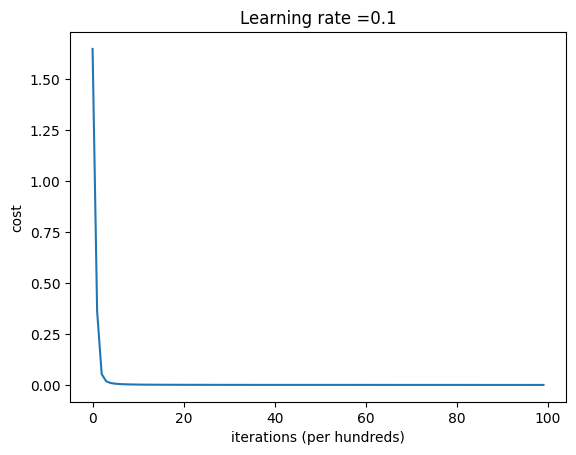


Deep Model Training Accuracy: 1.00

Plotting decision boundary for the deep model...


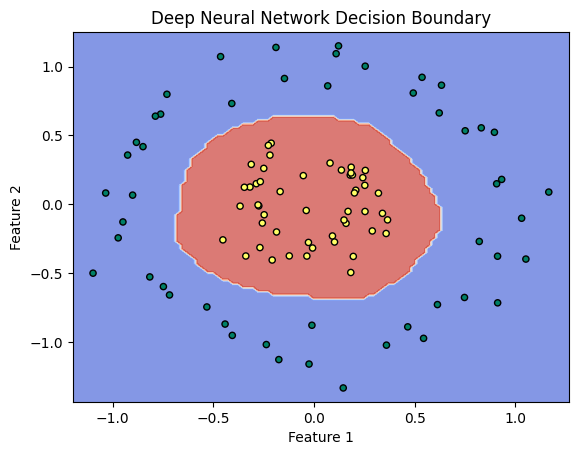

In [43]:
# Reshape X and y for the deep network functions
X_deep = X.T
y_deep = y.T

# Define the layer dimensions for a deep neural network
# Example: 2 input features, 4 hidden units, 3 hidden units, 1 output unit
layer_dims = [X_deep.shape[0], 20, 16, 5, 1]

# Train the L-layer model
parameters_deep = L_layer_model(X_deep, y_deep, layer_dims, num_iterations=10000, print_cost=True, learning_rate=0.1)

# Make predictions on the training data
y_pred_deep_train = predict_deep(X_deep, parameters_deep)
accuracy_deep_train = np.mean(y_pred_deep_train == y_deep)
print(f"\nDeep Model Training Accuracy: {accuracy_deep_train:.2f}")

# The original `plot_decision_boundary` function is for the 2-layer network.
# We use `plot_decision_boundary_deep` for the L-layer model.

# Let's adjust plot_decision_boundary to use predict_deep:
def plot_decision_boundary_deep(X, y, parameters, title="Deep Neural Network Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    grid_points = np.c_[xx.ravel(), yy.ravel()] # Shape (n_points, n_features)
    grid_points_T = grid_points.T # Transpose for deep_predict: (n_features, n_points)

    Z_deep = predict_deep(grid_points_T, parameters)

    Z_deep = Z_deep.reshape(xx.shape) # Reshape back to (height, width)

    plt.contourf(xx, yy, Z_deep, cmap='coolwarm', alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='summer', edgecolors='k', s=20)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

print("\nPlotting decision boundary for the deep model...")
plot_decision_boundary_deep(X, y, parameters_deep, title="Deep Neural Network Decision Boundary")

This project develops a Multi-Layer Perceptron (MLP) which, by definition, consists of multiple layers. Here's a summary of the layers in our neural network model:

Input Layer: This is the very first layer of the network. It receives the raw input data. For our make_circles dataset, each data point has two features (X and Y coordinates), so the input layer has 2 neurons.

Hidden Layers: These are the intermediate layers between the input and output layers where the bulk of the computation happens. They learn increasingly complex representations of the input data. In our L_layer_model:

We have defined three hidden layers.
The first hidden layer has 20 neurons.
The second hidden layer has 16 neurons.
The third hidden layer has 5 neurons.
All these hidden layers use the ReLU (Rectified Linear Unit) activation function, which helps the network learn non-linear patterns.
Output Layer: This is the final layer of the network that produces the prediction. Since this is a binary classification problem (distinguishing between two classes), the output layer has 1 neuron. It uses the Sigmoid activation function, which squashes the output to a value between 0 and 1, representing the probability of the input belonging to the positive class.

In summary, the entire network structure is defined by the layer_dims list, which is currently [2, 20, 16, 5, 1]:

2 for the input layer
20, 16, 5 for the three hidden layers
1 for the output layer.
This architecture allows the network to learn complex, non-linear decision boundaries, as demonstrated by the perfect classification on the make_circles dataset.